# Shoe Visual Product Search System (Fine-Tuned CLIP)

Pipeline: fine-tune CLIP's image encoder on shoe subcategories (supervised contrastive loss) -> generate embeddings with the fine-tuned encoder -> FAISS vector search -> SQLite metadata DB -> image upload -> visual results -> held-out Recall@K evaluation.

Dataset: UT-Zappos50K, hosted on Hugging Face at `saurabh0568/visual-search-zappos50k`.

## 1. Install dependencies

In [ ]:
!pip install huggingface_hub faiss-cpu ftfy regex tqdm --quiet
!pip install git+https://github.com/openai/CLIP.git --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## 2. Download dataset from Hugging Face

In [ ]:
from huggingface_hub import login
login(token="")

In [ ]:
from huggingface_hub import hf_hub_download
import zipfile, os

zip_path_images = hf_hub_download(
    repo_id="saurabh0568/visual-search-zappos50k",
    filename="ut-zap50k-images.zip",
    repo_type="dataset"
)

with zipfile.ZipFile(zip_path_images, 'r') as z:
    z.extractall("data")

print("Extracted to:", os.path.abspath("data"))

ut-zap50k-images.zip: reconstructing file:   0%|          |  0.00B /  305MB            

ut-zap50k-images.zip: downloading bytes:           |  0.00B            

Extracted to: /content/data


## 3. Build metadata table by walking folder structure

In [ ]:
import pandas as pd

records = []
root = "data/ut-zap50k-images"

for category in os.listdir(root):
    cat_path = os.path.join(root, category)
    if not os.path.isdir(cat_path):
        continue
    for subcat in os.listdir(cat_path):
        sub_path = os.path.join(cat_path, subcat)
        if not os.path.isdir(sub_path):
            continue
        for brand in os.listdir(sub_path):
            brand_path = os.path.join(sub_path, brand)
            if not os.path.isdir(brand_path):
                continue
            for fname in os.listdir(brand_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    records.append({
                        "product_id": f"{category}_{subcat}_{brand}_{fname}".replace(" ", "_"),
                        "path": os.path.join(brand_path, fname),
                        "category": category,
                        "subcategory": subcat,
                        "brand": brand,
                        "filename": fname
                    })

df = pd.DataFrame(records)
print(f"Total images found: {len(df)}")
df.head()

Total images found: 50025


,product_id,path,category,subcategory,brand,filename
0,Slippers_Slipper_Heels_L.B._Evans_7590239.72.jpg,data/ut-zap50k-images/Slippers/Slipper Heels/L...,Slippers,Slipper Heels,L.B. Evans,7590239.72.jpg
1,Slippers_Slipper_Heels_L.B._Evans_7590239.255.jpg,data/ut-zap50k-images/Slippers/Slipper Heels/L...,Slippers,Slipper Heels,L.B. Evans,7590239.255.jpg
2,Slippers_Slipper_Heels_Daniel_Green_105772.552...,data/ut-zap50k-images/Slippers/Slipper Heels/D...,Slippers,Slipper Heels,Daniel Green,105772.552.jpg
3,Slippers_Slipper_Heels_Daniel_Green_105772.72.jpg,data/ut-zap50k-images/Slippers/Slipper Heels/D...,Slippers,Slipper Heels,Daniel Green,105772.72.jpg
4,Slippers_Slipper_Heels_Daniel_Green_105772.468...,data/ut-zap50k-images/Slippers/Slipper Heels/D...,Slippers,Slipper Heels,Daniel Green,105772.46867.jpg


## 4. Sample a manageable subset (per category)

In [ ]:
PER_CATEGORY_LIMIT = 2500

subset = (
    df.groupby('category', group_keys=False)
      .apply(lambda x: x.sample(min(len(x), PER_CATEGORY_LIMIT), random_state=42))
      .reset_index(drop=True)
)

print(f"Subset size: {len(subset)}")
subset['category'].value_counts()

Subset size: 8783


/tmp/ipykernel_1702/9577486.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), PER_CATEGORY_LIMIT), random_state=42))


,count
category,
Boots,2500
Sandals,2500
Shoes,2500
Slippers,1283


## 5. Validate images (drop unreadable files)

A quick pass that just opens each image -- no model involved yet. Anything corrupted or unreadable is dropped now so every later step (splitting, training, embedding) can assume every row in `valid_df` is safe to open.

In [ ]:
from PIL import Image
from tqdm import tqdm

valid_rows = []
for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Validating images"):
    try:
        Image.open(row['path']).convert("RGB")
        valid_rows.append(row)
    except Exception:
        continue

valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)
print(f"Usable images: {len(valid_df)} / {len(subset)}")

Validating images: 100%|██████████| 8783/8783 [00:05<00:00, 1535.83it/s]


Usable images: 8783 / 8783


## 6. Set up metadata database (SQLite)

In [ ]:
import sqlite3

conn = sqlite3.connect("shoes_metadata.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS products (
    product_id TEXT PRIMARY KEY,
    path TEXT,
    category TEXT,
    subcategory TEXT,
    brand TEXT,
    filename TEXT,
    embedding_index INTEGER
)
""")
conn.commit()

print("Database initialized.")

Database initialized.


## 7. Load CLIP model (pretrained -- this is the base encoder we fine-tune below)

In [ ]:
import torch
import clip
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

Using device: cuda


100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 154MiB/s]


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

## 8. Fine-tune CLIP's image encoder on our shoe subcategories

Why this design:

- CLIP's off-the-shelf embeddings are general-purpose. Fine-tuning teaches the image encoder that *our* notion of "similar" (same subcategory, e.g. `Boots.Ankle` vs `Boots.Knee High`) maps to nearby vectors -- which is exactly what Recall@K measures.
- We only have image + category/subcategory/brand labels, no captions, so we skip CLIP's usual image-text contrastive objective and fine-tune with **supervised contrastive loss (SupCon, Khosla et al. 2020)** on the image encoder alone, using `subcategory` as the class label.
- We freeze all but the **last 2 transformer blocks** + the final projection of the visual encoder. Fine-tuning the whole ViT on ~10-15K images would risk catastrophic forgetting and overfitting; partial fine-tuning is standard practice for adapting frozen foundation models on modest data/compute.
- We hold out a validation split **before** any training happens, and the model never sees it, so the Recall@K reported later is a genuine leak-free generalization check, not memorization.

### 8.1 Held-out validation split (stratified by subcategory)

In [ ]:
from sklearn.model_selection import train_test_split

subcat_counts = valid_df['subcategory'].value_counts()
valid_subcats = subcat_counts[subcat_counts >= 8].index
filtered_mask = valid_df['subcategory'].isin(valid_subcats)
filtered_positions = np.where(filtered_mask.values)[0]  # positions into valid_df
filtered_df = valid_df.iloc[filtered_positions].reset_index(drop=True)

print(f"Excluded {len(valid_df) - len(filtered_df)} images from subcategories with <8 examples (train/val split only)")

train_pos_idx, val_pos_idx = train_test_split(
    np.arange(len(filtered_positions)),
    test_size=0.15,
    random_state=42,
    stratify=filtered_df['subcategory']
)
train_orig_idx = filtered_positions[train_pos_idx]
val_orig_idx = filtered_positions[val_pos_idx]

train_df = valid_df.iloc[train_orig_idx].reset_index(drop=True)
val_df = valid_df.iloc[val_orig_idx].reset_index(drop=True)

print(f"Train (fine-tuning + gallery): {len(train_df)} images | Val (held out, unseen during fine-tuning): {len(val_df)} images")

Excluded 13 images from subcategories with <8 examples (train/val split only)
Train (fine-tuning + gallery): 7454 images | Val (held out, unseen during fine-tuning): 1316 images


### 8.2 Balanced batch sampling

Supervised contrastive loss needs multiple examples of the *same* class inside a batch, or there's nothing to pull together. Plain random batches from an imbalanced dataset won't reliably provide that. We use a **P-K sampler**: each batch = `P` subcategories x `K` images per subcategory.

In [ ]:
from torch.utils.data import Dataset, DataLoader, Sampler
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_df['label_id'] = label_encoder.fit_transform(train_df['subcategory'])

class ShoeTrainDataset(Dataset):
    def __init__(self, df, preprocess):
        self.paths = df['path'].tolist()
        self.labels = df['label_id'].tolist()
        self.preprocess = preprocess

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = self.preprocess(Image.open(self.paths[idx]).convert("RGB"))
        return image, self.labels[idx]


class PKSampler(Sampler):
    def __init__(self, labels, P=8, K=4, batches_per_epoch=None):
        self.labels = np.array(labels)
        self.P, self.K = P, K
        self.label_to_indices = {}
        for i, lab in enumerate(self.labels):
            self.label_to_indices.setdefault(lab, []).append(i)
        self.valid_labels = [l for l, idxs in self.label_to_indices.items() if len(idxs) >= 2]
        self.batch_size = self.P * self.K
        self.batches_per_epoch = batches_per_epoch or max(1, len(self.labels) // self.batch_size)

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            n_p = min(self.P, len(self.valid_labels))
            chosen_labels = np.random.choice(self.valid_labels, size=n_p, replace=False)
            batch = []
            for lab in chosen_labels:
                idxs = self.label_to_indices[lab]
                replace = len(idxs) < self.K
                batch.extend(np.random.choice(idxs, size=self.K, replace=replace).tolist())
            yield batch

    def __len__(self):
        return self.batches_per_epoch


train_dataset = ShoeTrainDataset(train_df, preprocess)
pk_sampler = PKSampler(train_df['label_id'].tolist(), P=8, K=4)
train_loader = DataLoader(train_dataset, batch_sampler=pk_sampler, num_workers=2)

print(f"Batch size: {pk_sampler.batch_size} ({pk_sampler.P} subcategories x {pk_sampler.K} images) | "
      f"Batches/epoch: {len(pk_sampler)}")

Batch size: 32 (8 subcategories x 4 images) | Batches/epoch: 232


### 8.3 Partial unfreezing + supervised contrastive loss

Only the last 2 ViT blocks, the post-layernorm, and the final projection get gradients. Everything else (the other 10 blocks, patch embedding, positional embedding, and the entire text tower -- which we don't use for training) stays frozen.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

for param in model.parameters():
    param.requires_grad = False

N_UNFREEZE_BLOCKS = 2
visual_blocks = model.visual.transformer.resblocks
for block in visual_blocks[-N_UNFREEZE_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

for param in model.visual.ln_post.parameters():
    param.requires_grad = True
model.visual.proj.requires_grad = True

model = model.float()

trainable_params = [p for p in model.parameters() if p.requires_grad]
n_trainable = sum(p.numel() for p in trainable_params)
n_total = sum(p.numel() for p in model.parameters())
print(f"Training {n_trainable:,} / {n_total:,} parameters ({100*n_trainable/n_total:.2f}%)")


class SupConLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        features = F.normalize(features, dim=1)
        labels = labels.view(-1, 1)
        pos_mask = torch.eq(labels, labels.T).float().to(device)

        logits = torch.matmul(features, features.T) / self.temperature
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()  # numerical stability

        self_mask = torch.eye(pos_mask.shape[0], device=device)
        pos_mask = pos_mask * (1 - self_mask)

        exp_logits = torch.exp(logits) * (1 - self_mask)
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-12)

        num_pos = torch.clamp(pos_mask.sum(1), min=1)  # avoid div-by-zero if a batch has a singleton class
        mean_log_prob_pos = (pos_mask * log_prob).sum(1) / num_pos

        return -mean_log_prob_pos.mean()


criterion = SupConLoss(temperature=0.07)
optimizer = torch.optim.AdamW(trainable_params, lr=1e-6, weight_decay=1e-4)

Training 14,570,496 / 151,277,313 parameters (9.63%)


### 8.4 Training loop

Small learning rate (`1e-6`), mixed precision on GPU, a handful of epochs -- this is fine-tuning, not training from scratch. Watch the printed loss: it should trend down; if it's flat, the learning rate is too low or the batches aren't forming useful positive pairs.

In [ ]:
EPOCHS = 4
use_amp = (device == "cuda")
scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

model.train()
loss_history = []

for epoch in range(EPOCHS):
    epoch_losses = []
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            features = model.encode_image(images).float()
            loss = criterion(features, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        epoch_losses.append(loss.item())
        pbar.set_postfix(loss=float(np.mean(epoch_losses[-20:])))

    avg_loss = float(np.mean(epoch_losses))
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}: avg SupCon loss = {avg_loss:.4f}")

model.eval()
print("Fine-tuning complete.")

Epoch 1/4: 100%|██████████| 232/232 [00:25<00:00,  8.96it/s, loss=2.38]


Epoch 1: avg SupCon loss = 2.5962


Epoch 2/4: 100%|██████████| 232/232 [00:23<00:00,  9.91it/s, loss=2.19]


Epoch 2: avg SupCon loss = 2.3042


Epoch 3/4: 100%|██████████| 232/232 [00:23<00:00,  9.84it/s, loss=2.09]


Epoch 3: avg SupCon loss = 2.0839


Epoch 4/4: 100%|██████████| 232/232 [00:23<00:00,  9.75it/s, loss=1.96]

Epoch 4: avg SupCon loss = 1.9780
Fine-tuning complete.


## 9. Generate embeddings for the full catalog (fine-tuned encoder)

`model` was fine-tuned in place in Section 8, so `get_embedding` below already produces fine-tuned embeddings. This embeds every image in `valid_df` (train + val together) -- the full product catalog that the search system will serve results from.

In [ ]:
def get_embedding(img_path_or_file):
    image = preprocess(Image.open(img_path_or_file).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(image)
    return emb.cpu().numpy().flatten()

embeddings = np.array([
    get_embedding(p) for p in tqdm(valid_df['path'], desc="Embedding full catalog (fine-tuned)")
]).astype('float32')

print(f"Fine-tuned catalog embeddings: {embeddings.shape}")

Embedding full catalog (fine-tuned): 100%|██████████| 8783/8783 [01:30<00:00, 96.83it/s]

Fine-tuned catalog embeddings: (8783, 512)


## 10. Save embeddings + insert metadata into database

In [ ]:
np.save("embeddings_finetuned.npy", embeddings)

for idx, row in valid_df.iterrows():
    cursor.execute("""
        INSERT OR REPLACE INTO products
        (product_id, path, category, subcategory, brand, filename, embedding_index)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (row['product_id'], row['path'], row['category'], row['subcategory'],
          row['brand'], row['filename'], idx))

conn.commit()
print("Metadata saved to database. Rows:", cursor.execute("SELECT COUNT(*) FROM products").fetchone()[0])

Metadata saved to database. Rows: 8783


## 11. Build FAISS vector index

This is the **vector database** for this project: FAISS stores every fine-tuned embedding and performs the nearest-neighbor search. SQLite (above) only stores metadata (category, brand, path) and is linked to FAISS via `embedding_index`.

In [ ]:
import faiss

dim = embeddings.shape[1]
faiss.normalize_L2(embeddings)  # required for cosine similarity via inner product

index = faiss.IndexFlatIP(dim)
index.add(embeddings)
faiss.write_index(index, "shoes_finetuned.index")

print(f"FAISS index built with {index.ntotal} vectors of dimension {dim}")

FAISS index built with 8783 vectors of dimension 512


## 12. Core search function (embedding -> FAISS -> metadata from DB)

In [ ]:
def search_similar_shoes(query_img_path_or_file, top_k=5):
    query_emb = get_embedding(query_img_path_or_file).reshape(1, -1).astype('float32')
    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, top_k)

    results = []
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        cursor.execute(
            "SELECT product_id, path, category, subcategory, brand FROM products WHERE embedding_index = ?",
            (int(idx),)
        )
        row = cursor.fetchone()
        if row:
            results.append({
                "rank": rank + 1,
                "product_id": row[0],
                "path": row[1],
                "category": row[2],
                "subcategory": row[3],
                "brand": row[4],
                "similarity": float(score) * 100
            })
    return results

## 12.5 Guard against non-shoe uploads (zero-shot CLIP gate)

The fine-tuned encoder above only ever learned to tell shoe *subcategories* apart -- it was never shown a non-shoe image, so it has no real "this isn't a shoe" signal. An unrelated photo (furniture, a face, a pet) still gets mapped somewhere into shoe-embedding space and can produce a deceptively confident-looking top-K (this is exactly what happens if you upload, say, a photo of a table -- it can come back with several slippers at ~55-60% similarity).

Fix: load a **second, un-fine-tuned copy of CLIP** and use its native zero-shot image-text matching -- untouched, since fine-tuning only unfroze the last 2 visual blocks -- to check "does this look like a shoe?" before the fine-tuned retrieval runs at all.


In [ ]:
# A separate, never-fine-tuned CLIP instance, kept purely for this zero-shot check
gate_model, gate_preprocess = clip.load("ViT-B/32", device=device)
gate_model.eval()

SHOE_PROMPTS = [
    "a photo of a shoe",
    "a photo of a sneaker",
    "a photo of a boot",
    "a photo of a sandal",
    "a photo of a slipper",
    "a photo of a pair of shoes",
]

NON_SHOE_PROMPTS = [
    "a photo of furniture",
    "a photo of a person",
    "a photo of an animal",
    "a photo of food",
    "a photo of a vehicle",
    "a photo of a building or room",
    "a photo of an electronic device",
    "a photo of clothing that is not footwear",
    "a photo of a landscape or nature scene",
    "a photo of something unrelated to shoes",
]

ALL_GATE_PROMPTS = SHOE_PROMPTS + NON_SHOE_PROMPTS
gate_text_tokens = clip.tokenize(ALL_GATE_PROMPTS).to(device)
with torch.no_grad():
    gate_text_features = gate_model.encode_text(gate_text_tokens)
    gate_text_features = gate_text_features / gate_text_features.norm(dim=-1, keepdim=True)

# Tune this by testing a few real shoe photos and a few obviously unrelated photos
# below, and setting the threshold between the two confidence clusters you see.
SHOE_GATE_THRESHOLD = 0.5

def shoe_confidence(img_path_or_file):
    """Probability mass (0-1) assigned to shoe-related prompts vs. everything else."""
    image = gate_preprocess(Image.open(img_path_or_file).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = gate_model.encode_image(image)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        similarity = (100.0 * image_features @ gate_text_features.T).softmax(dim=-1)
    probs = similarity.cpu().numpy().flatten()
    return float(probs[:len(SHOE_PROMPTS)].sum())

def is_shoe_image(img_path_or_file, threshold=SHOE_GATE_THRESHOLD):
    confidence = shoe_confidence(img_path_or_file)
    return confidence >= threshold, confidence

print("Gate ready. Sanity check: try it on a shoe photo vs. a random non-shoe photo")
print("via is_shoe_image('path/to/image.jpg') before relying on it below.")


Gate ready. Sanity check: try it on a shoe photo vs. a random non-shoe photo
via is_shoe_image('path/to/image.jpg') before relying on it below.


## 13. Upload your own shoe image and view results (interactive, Colab-native)

Run this cell, click **Choose Files**, upload a shoe photo, and it will display your query image alongside the top-K similar shoes (retrieved using the fine-tuned encoder) with similarity scores.

Upload a shoe image:


Saving Screenshot 2026-09-05 115947.png to Screenshot 2026-09-05 115947.png

Query image: Screenshot 2026-09-05 115947.png
Shoe-likelihood (zero-shot gate): 80.9%

Top matches (fine-tuned CLIP):
  #1  Osiris  |  Shoes/Sneakers and Athletic Shoes  |  similarity: 77.02%
  #2  Nike Action Kids  |  Shoes/Sneakers and Athletic Shoes  |  similarity: 74.76%
  #3  Nike  |  Shoes/Sneakers and Athletic Shoes  |  similarity: 74.67%
  #4  Nike  |  Shoes/Sneakers and Athletic Shoes  |  similarity: 74.28%
  #5  Vans Kids  |  Shoes/Sneakers and Athletic Shoes  |  similarity: 74.23%


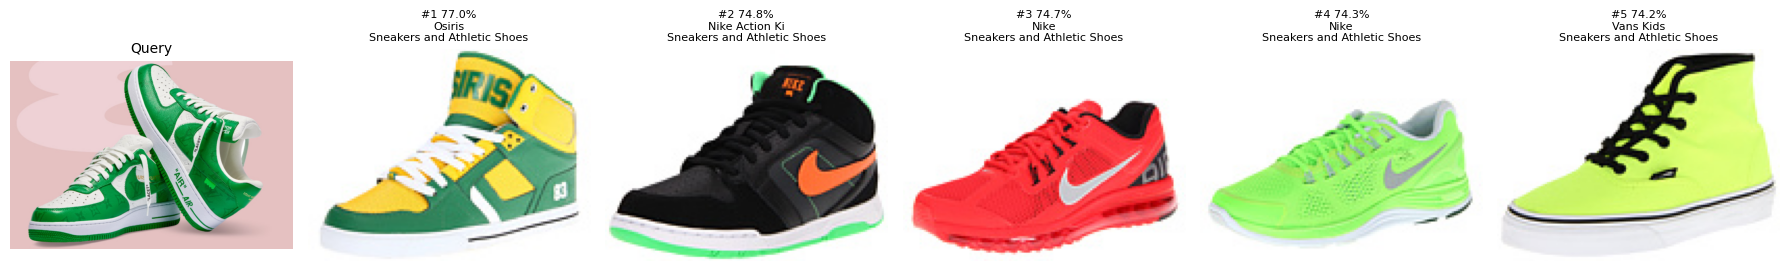

In [ ]:
from google.colab import files
import matplotlib.pyplot as plt

LOW_CONFIDENCE_SIMILARITY = 55  # below this top-1 %, flag the match as unreliable

def show_results(query_path, results):
    n = len(results) + 1
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))

    axes[0].imshow(Image.open(query_path).convert("RGB"))
    axes[0].set_title("Query", fontsize=10)
    axes[0].axis('off')

    for i, r in enumerate(results):
        axes[i + 1].imshow(Image.open(r['path']).convert("RGB"))
        axes[i + 1].set_title(f"#{r['rank']} {r['similarity']:.1f}%\n{r['brand'][:14]}\n{r['subcategory']}", fontsize=8)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

print("Upload a shoe image:")
uploaded = files.upload()

for fname in uploaded.keys():
    query_path = fname
    print(f"\nQuery image: {query_path}")

    passed_gate, gate_confidence = is_shoe_image(query_path)
    print(f"Shoe-likelihood (zero-shot gate): {gate_confidence:.1%}")

    if not passed_gate:
        print("This doesn't look like a shoe -- skipping retrieval. "
              "Try a clearer photo of a single shoe, boot, sandal, or slipper.")
        continue

    results = search_similar_shoes(query_path, top_k=5)

    if results and results[0]['similarity'] < LOW_CONFIDENCE_SIMILARITY:
        print(f"Low-confidence match (top similarity {results[0]['similarity']:.1f}%) "
              f"-- results below may not be reliable.")

    print("\nTop matches (fine-tuned CLIP):")
    for r in results:
        print(f"  #{r['rank']}  {r['brand']}  |  {r['category']}/{r['subcategory']}  |  similarity: {r['similarity']:.2f}%")

    show_results(query_path, results)


## 14. Evaluate: Recall@K on held-out validation set (fine-tuned CLIP)

Gallery = train images, queries = held-out val images the model never saw during fine-tuning. A hit = the query's subcategory appears anywhere in the top-K retrieved gallery items. Both galleries and queries are sliced straight out of the catalog embeddings from Section 9 using the split positions from Section 8.1 -- no re-embedding needed, and the split guarantees this is leak-free.

In [ ]:
def build_faiss_index(emb):
    e = emb.copy()
    faiss.normalize_L2(e)
    idx = faiss.IndexFlatIP(e.shape[1])
    idx.add(e)
    return idx

def recall_at_k(gallery_index, gallery_labels, query_emb, query_labels, k=5):
    q = query_emb.copy()
    faiss.normalize_L2(q)
    _, indices = gallery_index.search(q, k)
    hits = sum(
        query_labels[i] in [gallery_labels[j] for j in retrieved]
        for i, retrieved in enumerate(indices)
    )
    return hits / len(query_labels)

gallery_emb = embeddings[train_orig_idx].copy()
query_emb = embeddings[val_orig_idx].copy()
gallery_labels = train_df['subcategory'].tolist()
query_labels = val_df['subcategory'].tolist()

eval_index = build_faiss_index(gallery_emb)

print("Recall@K -- fine-tuned CLIP, held-out validation queries vs. training gallery (leak-free)\n")
recall_results = {}
for k in [1, 5, 10]:
    r = recall_at_k(eval_index, gallery_labels, query_emb, query_labels, k=k)
    recall_results[k] = r
    print(f"Recall@{k:<2}: {r:.2%}")

Recall@K -- fine-tuned CLIP, held-out validation queries vs. training gallery (leak-free)

Recall@1 : 81.91%
Recall@5 : 94.91%
Recall@10: 97.26%


### 14.1 Plot Recall@K

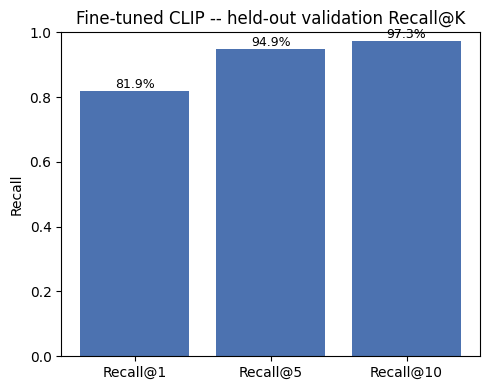

In [ ]:
ks = list(recall_results.keys())
vals = [recall_results[k] for k in ks]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([f"Recall@{k}" for k in ks], vals, color="#4C72B0")
for i, v in enumerate(vals):
    ax.text(i, v + 0.01, f"{v:.1%}", ha='center', fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Recall")
ax.set_title("Fine-tuned CLIP -- held-out validation Recall@K")
plt.tight_layout()
plt.show()

## 15. Save fine-tuning artifacts

In [ ]:
import shutil

os.makedirs("saved_artifacts", exist_ok=True)
torch.save(model.visual.state_dict(), "clip_visual_finetuned.pt")

shutil.copy("clip_visual_finetuned.pt", "saved_artifacts/")
shutil.copy("embeddings_finetuned.npy", "saved_artifacts/")
shutil.copy("shoes_finetuned.index", "saved_artifacts/")
shutil.copy("shoes_metadata.db", "saved_artifacts/")

print("Fine-tuned encoder weights, embeddings, FAISS index, and metadata DB saved to ./saved_artifacts/")

Fine-tuned encoder weights, embeddings, FAISS index, and metadata DB saved to ./saved_artifacts/


## 16. Save the fine-tuned model for the inference app

The VS Code / Gradio app only needs the **visual encoder** weights (it never needs the text tower). This re-saves them under `model/weights/` matching the project structure the Gradio app expects, alongside a small metadata file recording which CLIP backbone they belong to.


In [ ]:
import json

os.makedirs("model/weights", exist_ok=True)

torch.save(model.visual.state_dict(), "model/weights/clip_visual_finetuned.pt")

with open("model/weights/model_config.json", "w") as f:
    json.dump({
        "clip_model_name": "ViT-B/32",
        "embedding_dim": int(embeddings.shape[1]),
        "n_unfreeze_blocks": N_UNFREEZE_BLOCKS,
        "epochs": EPOCHS,
    }, f, indent=2)

print("Saved fine-tuned visual encoder to model/weights/clip_visual_finetuned.pt")
print("Copy the whole model/weights/ folder into the VS Code project.")


Saved fine-tuned visual encoder to model/weights/clip_visual_finetuned.pt
Copy the whole model/weights/ folder into the VS Code project.


## 17. Export the catalog (images + metadata + embeddings) for Postgres/pgvector

The Gradio app stores catalog images and embeddings in Postgres (not on disk), so the app itself never needs the raw UT-Zappos50K files. This cell re-saves every catalog image as a JPEG under `export_for_app/catalog_images/`, and writes one JSON record per product (metadata + its fine-tuned embedding) to `export_for_app/catalog_export.json`. The `db/ingest.py` script in the VS Code project reads exactly this format.

Note: `embeddings` was already L2-normalized in place by `faiss.normalize_L2` in Section 11, so these exported vectors are ready for cosine-distance search via pgvector's `<=>` operator with no extra normalization needed downstream.


In [ ]:
EXPORT_DIR = "export_for_app"
IMAGES_DIR = os.path.join(EXPORT_DIR, "catalog_images")
os.makedirs(IMAGES_DIR, exist_ok=True)

export_records = []
for i, row in tqdm(valid_df.iterrows(), total=len(valid_df), desc="Exporting catalog images"):
    dest_name = f"{row['product_id']}.jpg"
    dest_path = os.path.join(IMAGES_DIR, dest_name)

    # Re-save as JPEG so every catalog image ingested into Postgres is a consistent,
    # predictable format regardless of the original file type.
    img = Image.open(row['path']).convert("RGB")
    img.save(dest_path, "JPEG", quality=90)

    export_records.append({
        "product_id": row['product_id'],
        "image_filename": dest_name,
        "category": row['category'],
        "subcategory": row['subcategory'],
        "brand": row['brand'],
        "embedding": embeddings[i].tolist(),  # fine-tuned, L2-normalized
    })

with open(os.path.join(EXPORT_DIR, "catalog_export.json"), "w") as f:
    json.dump(export_records, f)

print(f"Exported {len(export_records)} catalog rows + images to ./{EXPORT_DIR}/")


Exporting catalog images: 100%|██████████| 8783/8783 [00:06<00:00, 1272.53it/s]


Exported 8783 catalog rows + images to ./export_for_app/
